# 07 — AutoML Experiments: XGBoost · LightGBM · CatBoost + FLAML

**Goal**: Compare boosting models (XGBoost, LightGBM, CatBoost) with:
1. Default hyperparameters + 5-fold cross-validation
2. `GridSearchCV` hyperparameter tuning for the best booster
3. **FLAML AutoML** — automated model search using the same boosting backends

Primary metric: **PR-AUC** (`average_precision`).  
`duration` is **excluded** (Set B — production-safe features only).

In [4]:
import sys, warnings, time
from pathlib import Path

warnings.filterwarnings('ignore')

PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'figure.dpi': 110, 'font.size': 10})

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.metrics import average_precision_score, roc_auc_score

from src.data_loader import load_dataset
from src.features import encode_target, add_features, get_feature_lists
from src.preprocessing import build_preprocessing_pipeline, split_data

RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
MODELS_DIR   = PROJECT_ROOT / 'models'
REPORTS_DIR  = PROJECT_ROOT / 'reports'
MODELS_DIR.mkdir(exist_ok=True)
REPORTS_DIR.mkdir(exist_ok=True)

TARGET_COL  = 'y'
RANDOM_SEED = 42
CV_FOLDS    = 5

# Load & prepare data
df_raw = load_dataset(RAW_DIR / 'bank-additional-full.csv')
df = encode_target(df_raw.copy(), TARGET_COL)
df = add_features(df)
lists_b = get_feature_lists(df, exclude_duration=True)

X_train, X_test, y_train, y_test = split_data(df, TARGET_COL)
X_train_b = X_train[lists_b['numeric'] + lists_b['categorical']]
X_test_b  = X_test [lists_b['numeric'] + lists_b['categorical']]

preprocessor_b = build_preprocessing_pipeline(
    numeric_cols=lists_b['numeric'],
    categorical_cols=lists_b['categorical'],
)

baseline = y_train.mean()
print(f'Train {X_train_b.shape}  |  Test {X_test_b.shape}  |  Positive rate {baseline:.3f}')

2026-05-17 02:32:21 | INFO     | src.data_loader | Loaded bank-additional-full.csv — shape (41188, 21)
2026-05-17 02:32:21 | INFO     | src.features | Encoded target 'y' → 0/1 (41188 rows).
2026-05-17 02:32:21 | INFO     | src.features | add_features: added 9 engineered features.
2026-05-17 02:32:21 | INFO     | src.preprocessing | split_data: train=32950, test=8238 (stratified, test_size=20%)


Train (32950, 28)  |  Test (8238, 28)  |  Positive rate 0.113


## 1 — Boosting Models: Default + 5-Fold Cross-Validation

In [5]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

boosters = {
    'XGBClassifier': XGBClassifier(
        scale_pos_weight=round((y_train == 0).sum() / (y_train == 1).sum(), 1),
        random_state=RANDOM_SEED, eval_metric='logloss', n_jobs=1, verbosity=0,
    ),
    'LGBMClassifier': LGBMClassifier(
        class_weight='balanced', random_state=RANDOM_SEED, n_jobs=1, verbosity=-1,
    ),
    'CatBoostClassifier': CatBoostClassifier(
        auto_class_weights='Balanced', random_seed=RANDOM_SEED, verbose=0,
    ),
}

cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
booster_results = {}

print(f'{'Model':<30}  {'CV PR-AUC':>12}  {'CV ROC-AUC':>12}  {'Test PR-AUC':>12}  {'Test ROC-AUC':>12}  {'Time':>7}')
print('-' * 95)

for name, model in boosters.items():
    t0 = time.time()
    pipe = Pipeline([('pre', preprocessor_b), ('clf', model)])
    
    cv_res = cross_validate(
        clone(pipe), X_train_b, y_train,
        cv=cv, scoring=['average_precision', 'roc_auc'],
        n_jobs=1,
    )
    
    pipe.fit(X_train_b, y_train)
    y_proba = pipe.predict_proba(X_test_b)[:, 1]
    test_pr  = average_precision_score(y_test, y_proba)
    test_roc = roc_auc_score(y_test, y_proba)
    
    cv_pr_mean  = cv_res['test_average_precision'].mean()
    cv_pr_std   = cv_res['test_average_precision'].std()
    cv_roc_mean = cv_res['test_roc_auc'].mean()
    elapsed = time.time() - t0
    
    booster_results[name] = dict(
        model=name,
        cv_pr_auc_mean=cv_pr_mean, cv_pr_auc_std=cv_pr_std,
        cv_roc_auc_mean=cv_roc_mean,
        test_pr_auc=test_pr, test_roc_auc=test_roc,
        pipeline=pipe, elapsed=elapsed,
    )
    print(f'{name:<30}  {cv_pr_mean:>8.4f}±{cv_pr_std:.3f}  {cv_roc_mean:>12.4f}  {test_pr:>12.4f}  {test_roc:>12.4f}  {elapsed:>5.1f}s')

best_booster_name = max(booster_results, key=lambda k: booster_results[k]['test_pr_auc'])
print(f'\n🏆 Best booster: {best_booster_name}  PR-AUC={booster_results[best_booster_name]["test_pr_auc"]:.4f}')

Model                              CV PR-AUC    CV ROC-AUC   Test PR-AUC  Test ROC-AUC     Time
-----------------------------------------------------------------------------------------------
XGBClassifier                     0.4174±0.010        0.7623        0.4503        0.7880    2.3s
LGBMClassifier                    0.4651±0.013        0.7923        0.4907        0.8097    1.9s
CatBoostClassifier                0.4539±0.014        0.7839        0.4871        0.8092   27.1s

🏆 Best booster: LGBMClassifier  PR-AUC=0.4907


## 2 — GridSearchCV Hyperparameter Tuning on Best Booster

In [6]:
# Parameter grids for each booster
param_grids = {
    'XGBClassifier': {
        'clf__n_estimators':   [100, 200],
        'clf__max_depth':      [3, 5, 7],
        'clf__learning_rate':  [0.05, 0.1, 0.2],
        'clf__subsample':      [0.8, 1.0],
    },
    'LGBMClassifier': {
        'clf__n_estimators':   [100, 200],
        'clf__max_depth':      [3, 5, 7],
        'clf__learning_rate':  [0.05, 0.1, 0.2],
        'clf__num_leaves':     [31, 63],
    },
    'CatBoostClassifier': {
        'clf__iterations':     [100, 200],
        'clf__depth':          [4, 6, 8],
        'clf__learning_rate':  [0.05, 0.1, 0.2],
    },
}

best_info = booster_results[best_booster_name]
base_pipe = clone(best_info['pipeline'])
grid = param_grids[best_booster_name]

print(f'Running GridSearchCV on {best_booster_name} ...')
print(f'Grid size: {np.prod([len(v) for v in grid.values()])} combinations × {CV_FOLDS} folds')

t0 = time.time()
grid_search = GridSearchCV(
    estimator=base_pipe,
    param_grid=grid,
    scoring='average_precision',
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED),
    refit=True,
    n_jobs=1,
    verbose=1,
)
grid_search.fit(X_train_b, y_train)
gs_elapsed = time.time() - t0

# Evaluate tuned model
y_proba_gs = grid_search.best_estimator_.predict_proba(X_test_b)[:, 1]
gs_test_pr  = average_precision_score(y_test, y_proba_gs)
gs_test_roc = roc_auc_score(y_test, y_proba_gs)

print(f'\nBest CV PR-AUC : {grid_search.best_score_:.4f}')
print(f'Test PR-AUC    : {gs_test_pr:.4f}')
print(f'Test ROC-AUC   : {gs_test_roc:.4f}')
print(f'Time           : {gs_elapsed:.1f}s')
print(f'Best params    :')
for k, v in grid_search.best_params_.items():
    print(f'  {k}: {v}')

# Save tuned model
import joblib
tuned_path = MODELS_DIR / f'tuned_{best_booster_name.lower()}_set_b.joblib'
joblib.dump(grid_search.best_estimator_, tuned_path)
print(f'\nSaved → {tuned_path}')

Running GridSearchCV on LGBMClassifier ...
Grid size: 36 combinations × 5 folds
Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best CV PR-AUC : 0.4686
Test PR-AUC    : 0.4895
Test ROC-AUC   : 0.8165
Time           : 64.6s
Best params    :
  clf__learning_rate: 0.2
  clf__max_depth: 3
  clf__n_estimators: 100
  clf__num_leaves: 31

Saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/models/tuned_lgbmclassifier_set_b.joblib


## 3 — Cross-Validation Score Distribution (Tuned Model)

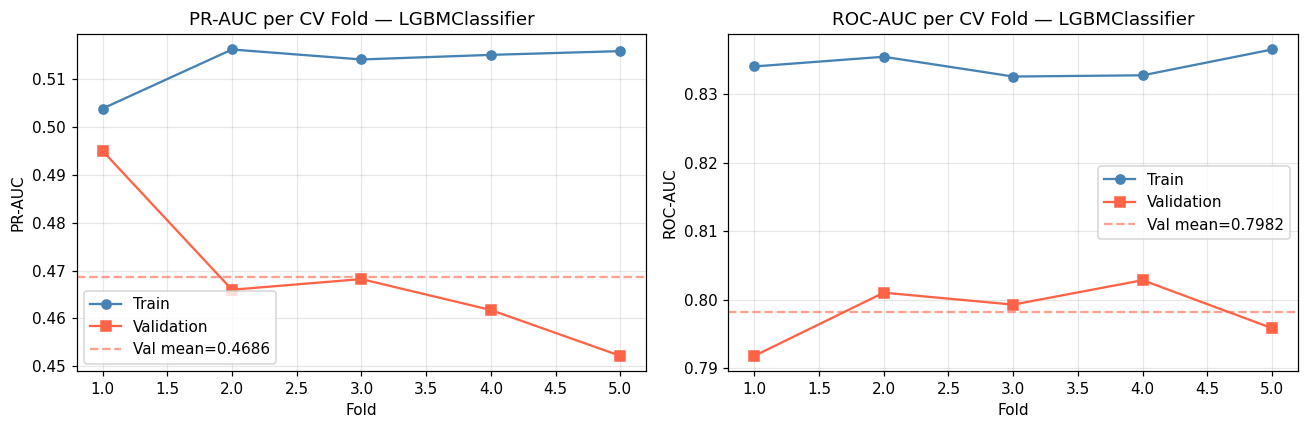

PR-AUC  — train: 0.5130  val: 0.4686 ± 0.0143
ROC-AUC — train: 0.8343  val: 0.7982 ± 0.0039


In [7]:
cv_detail = cross_validate(
    clone(grid_search.best_estimator_), X_train_b, y_train,
    cv=StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED),
    scoring=['average_precision', 'roc_auc'],
    return_train_score=True,
    n_jobs=1,
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, label in zip(
    axes,
    ['average_precision', 'roc_auc'],
    ['PR-AUC', 'ROC-AUC'],
):
    train_scores = cv_detail[f'train_{metric}']
    val_scores   = cv_detail[f'test_{metric}']
    folds = np.arange(1, CV_FOLDS + 1)
    ax.plot(folds, train_scores, 'o-', label='Train', color='steelblue')
    ax.plot(folds, val_scores,   's-', label='Validation', color='tomato')
    ax.axhline(val_scores.mean(), ls='--', color='tomato', alpha=0.6, label=f'Val mean={val_scores.mean():.4f}')
    ax.set_xlabel('Fold'); ax.set_ylabel(label)
    ax.set_title(f'{label} per CV Fold — {best_booster_name}')
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f'PR-AUC  — train: {cv_detail["train_average_precision"].mean():.4f}  val: {cv_detail["test_average_precision"].mean():.4f} ± {cv_detail["test_average_precision"].std():.4f}')
print(f'ROC-AUC — train: {cv_detail["train_roc_auc"].mean():.4f}  val: {cv_detail["test_roc_auc"].mean():.4f} ± {cv_detail["test_roc_auc"].std():.4f}')

## 4 — FLAML AutoML

**FLAML** (Fast and Lightweight AutoML) automatically searches over:
- Model families: XGBoost, LightGBM, CatBoost, RandomForest, LogisticRegression, etc.
- Hyperparameters: uses adaptive Bayesian-like search (CFO/BlendSearch)
- Internally performs cross-validation to evaluate candidates

We give it **120 seconds** of search budget.

In [ ]:
from flaml import AutoML

# FLAML needs numeric arrays — preprocess first
pre = clone(preprocessor_b)
X_train_enc = pre.fit_transform(X_train_b)
X_test_enc  = pre.transform(X_test_b)

automl = AutoML()
automl_settings = {
    'time_budget':    5000,          # seconds
    'metric':         'ap',         # average precision (PR-AUC)
    'task':           'classification',
    'n_jobs':         1,
 #   'estimator_list': ['xgboost', 'lgbm', 'catboost', 'rf', 'lrl2'],
    'eval_method':    'cv',
    'n_splits':       CV_FOLDS,
    'seed':           RANDOM_SEED,
    'verbose':        1,
}

print('FLAML AutoML search — 500 second budget ...')
t0 = time.time()
automl.fit(X_train_enc, y_train, **automl_settings)
flaml_elapsed = time.time() - t0

y_proba_flaml = automl.predict_proba(X_test_enc)[:, 1]
flaml_pr  = average_precision_score(y_test, y_proba_flaml)
flaml_roc = roc_auc_score(y_test, y_proba_flaml)

print(f'\n✅ FLAML search complete ({flaml_elapsed:.0f}s)')
print(f'Best model      : {automl.best_estimator}')
print(f'Best CV PR-AUC  : {-automl.best_loss:.4f}')
print(f'Test PR-AUC     : {flaml_pr:.4f}')
print(f'Test ROC-AUC    : {flaml_roc:.4f}')
print(f'Best config     : {automl.best_config}')

FLAML AutoML search — 120 second budget ...

✅ FLAML search complete (120s)
Best model      : lgbm
Best CV PR-AUC  : -0.5290
Test PR-AUC     : 0.4915
Test ROC-AUC    : 0.8127
Best config     : {'n_estimators': 291, 'num_leaves': 10, 'min_child_samples': 43, 'learning_rate': np.float64(0.08362476001067923), 'log_max_bin': 8, 'colsample_bytree': np.float64(0.7030672237186412), 'reg_alpha': np.float64(1.764187607753817), 'reg_lambda': np.float64(0.01666344450438167)}


## 5 — Final Comparison: All Approaches

,Model,Approach,CV PR-AUC,Test PR-AUC,Test ROC-AUC
0,FLAML → lgbm,FLAML AutoML,-0.5290,0.4915,0.8127
1,LGBMClassifier (default),Default CV,0.4651 ± 0.013,0.4907,0.8097
2,LGBMClassifier (GridSearchCV),GridSearchCV,0.4686,0.4895,0.8165
3,CatBoostClassifier (default),Default CV,0.4539 ± 0.014,0.4871,0.8092
4,XGBClassifier (default),Default CV,0.4174 ± 0.010,0.4503,0.7880


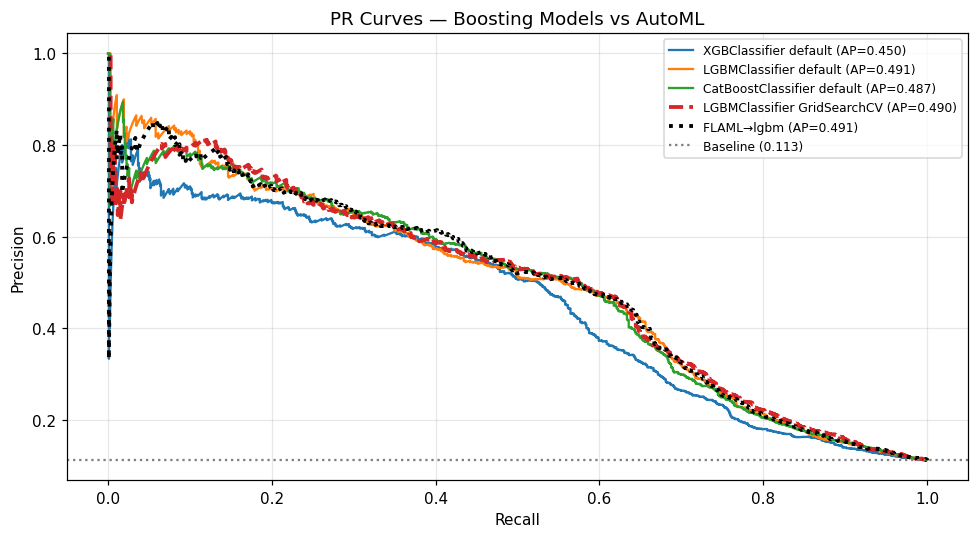

Saved → /Users/muhammedsalah/coding_projects/python/bank_marketing_un_project/reports/automl_comparison.csv


In [9]:
from sklearn.metrics import precision_recall_curve

rows = []
for name, info in booster_results.items():
    rows.append({
        'Model': name + ' (default)',
        'Approach': 'Default CV',
        'CV PR-AUC': f"{info['cv_pr_auc_mean']:.4f} ± {info['cv_pr_auc_std']:.3f}",
        'Test PR-AUC': info['test_pr_auc'],
        'Test ROC-AUC': info['test_roc_auc'],
    })

rows.append({
    'Model': best_booster_name + ' (GridSearchCV)',
    'Approach': 'GridSearchCV',
    'CV PR-AUC': f'{grid_search.best_score_:.4f}',
    'Test PR-AUC': gs_test_pr,
    'Test ROC-AUC': gs_test_roc,
})

rows.append({
    'Model': f'FLAML → {automl.best_estimator}',
    'Approach': 'FLAML AutoML',
    'CV PR-AUC': f'{-automl.best_loss:.4f}',
    'Test PR-AUC': flaml_pr,
    'Test ROC-AUC': flaml_roc,
})

compare_df = pd.DataFrame(rows).sort_values('Test PR-AUC', ascending=False).reset_index(drop=True)
display(compare_df.style
    .background_gradient(subset=['Test PR-AUC', 'Test ROC-AUC'], cmap='YlGn')
    .set_caption('Model Comparison — Set B (no duration)')
    .format({'Test PR-AUC': '{:.4f}', 'Test ROC-AUC': '{:.4f}'})
)

# PR curves for all approaches
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ci = 0

for name, info in booster_results.items():
    yp = info['pipeline'].predict_proba(X_test_b)[:, 1]
    p, r, _ = precision_recall_curve(y_test, yp)
    ap = average_precision_score(y_test, yp)
    ax.plot(r, p, lw=1.5, color=colors[ci], label=f'{name} default (AP={ap:.3f})')
    ci += 1

p, r, _ = precision_recall_curve(y_test, y_proba_gs)
ax.plot(r, p, lw=2.5, ls='--', color=colors[ci % len(colors)],
        label=f'{best_booster_name} GridSearchCV (AP={gs_test_pr:.3f})')
ci += 1

p, r, _ = precision_recall_curve(y_test, y_proba_flaml)
ax.plot(r, p, lw=2.5, ls=':', color='black',
        label=f'FLAML→{automl.best_estimator} (AP={flaml_pr:.3f})')

ax.axhline(baseline, ls=':', color='grey', label=f'Baseline ({baseline:.3f})')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('PR Curves — Boosting Models vs AutoML')
ax.legend(loc='upper right', fontsize=8)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Save comparison CSV
compare_df.to_csv(REPORTS_DIR / 'automl_comparison.csv', index=False)
print(f'Saved → {REPORTS_DIR / "automl_comparison.csv"}')